In [1]:
using MarineHydro
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length, u, @u_str
using LinearAlgebra: cross, dot, norm
using DifferentiationInterface 
import ForwardDiff 

In [2]:
function rectangular_lid_mesh(x_min::Real, x_max::Real, y_min::Real, y_max::Real, n_panels_x::Int, n_panels_y::Int, z_value::Real=0.0)
    # 1. Create a flat 2D CartesianGrid
    start_point = Meshes.Point(x_min, y_min)
    end_point   = Meshes.Point(x_max, y_max)
    grid = Meshes.CartesianGrid(start_point, end_point, dims=(n_panels_x, n_panels_y))

    # 2. Extract the 2D vertices and elevate them to 3D
    verts2d = Meshes.vertices(grid)
    verts3d = map(verts2d) do v
        vec_coords = Meshes.to(v)
        z_with_unit = z_value * u"m"
        Meshes.Point(vec_coords[1], vec_coords[2], z_with_unit)
    end

    # 3. Extract the connectivity indices natively from the grid elements
    # This unpacks the quad-panel connections explicitly
    connec = [Meshes.connect(Tuple(e.indices)) for e in Meshes.topology(grid)]

    # 4. Construct the SimpleMesh using an explicit unstructured configuration
    return Meshes.SimpleMesh(verts3d, connec)
end


rectangular_lid_mesh (generic function with 2 methods)

In [3]:
function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real, show_lid::Bool=false)

    n_panels_x = Int(ceil((x_max_lid-x_min_lid)/(2*faces_max_radius)))
    n_panels_y = Int(ceil((y_max_lid-y_min_lid)/(2*faces_max_radius)))

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end


function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real)
    return generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius, false)
end



generate_lid (generic function with 2 methods)

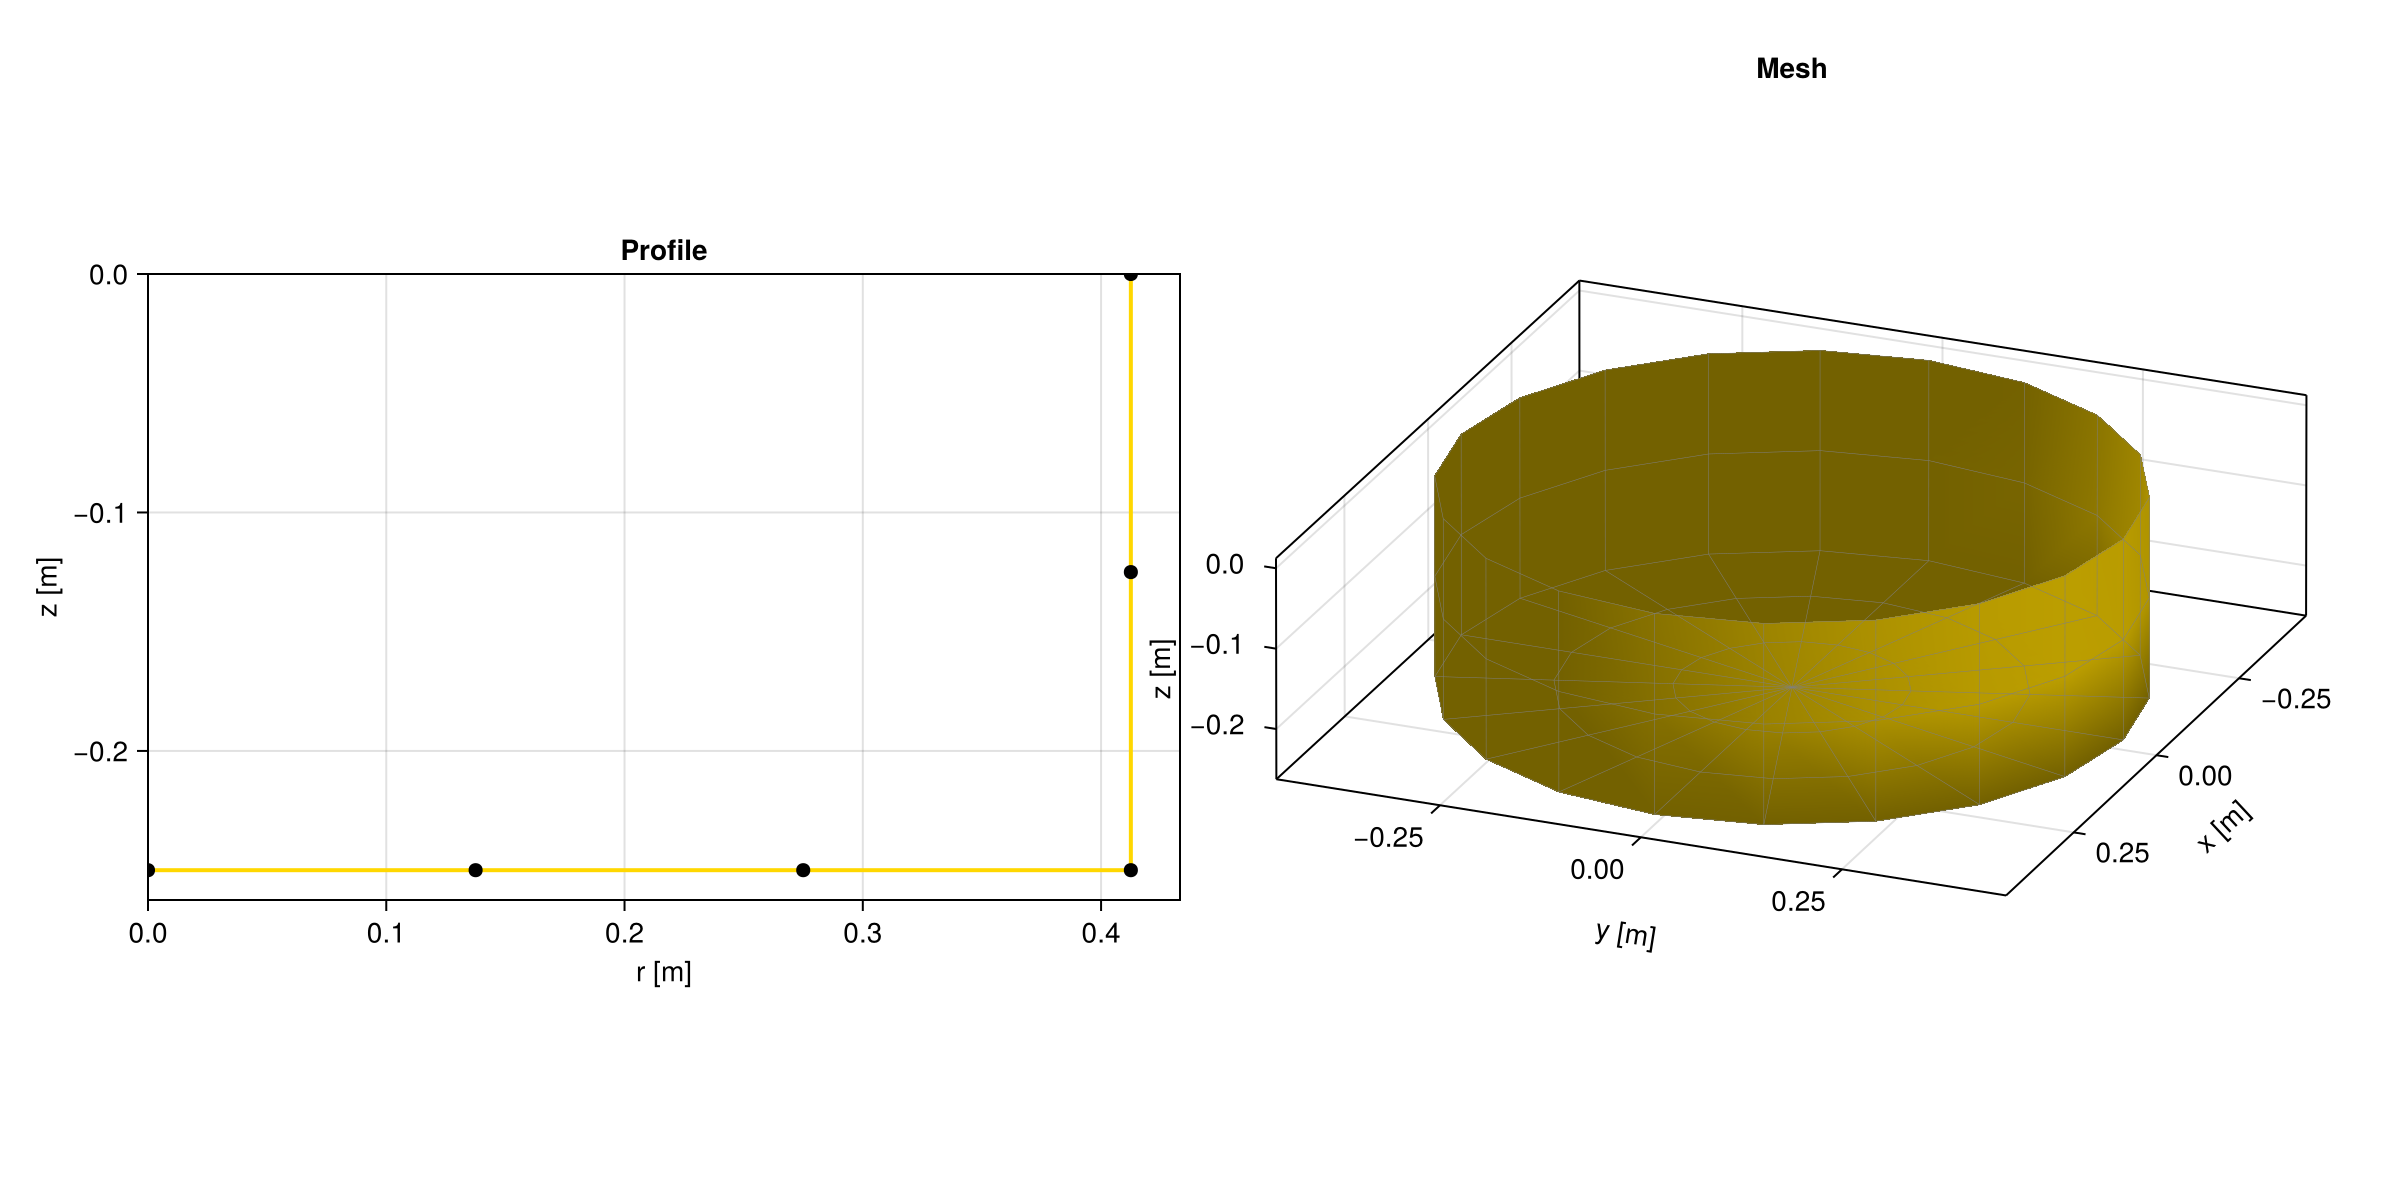

Mesh([0.41250000000000003 0.0 0.0; 0.39231081297175086 0.12746951017966582 0.0; … ; 0.1307702709905836 -0.0424898367265553 -0.25; 0.0 0.0 -0.25], [0 20 21 1; 1 21 22 2; … ; 98 100 99 99; 99 100 80 80], Number[0.4024054064858754 0.06373475508983291 -0.0625; 0.3630151615757083 0.1849654633751555 -0.0625; … ; 0.08067003590571296 -0.04110343630559013 -0.25; 0.08942342366352789 -0.014163278908851766 -0.25], Number[0.9876883405951377 0.15643446504023106 0.0; 0.8910065241883679 0.45399049973954664 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.01613230420727381, 0.01613230420727381, 0.01613230420727381, 0.016132304207273806, 0.01613230420727381, 0.016132304207273806, 0.016132304207273813, 0.016132304207273802, 0.016132304207273816, 0.016132304207273806  …  0.0029211762749506713, 0.0029211762749506796, 0.002921176274950675, 0.0029211762749506752, 0.002921176274950675, 0.0029211762749506757, 0.0029211762749506744, 0.0029211762749506752, 0.002921176274950676, 0.002921176274950677], Number[0.0898346805

In [4]:
radii_upper = 1.0
radii_lower = 0.1
draft_upper = 2.0
draft_lower = 0.25



r_initial = 0.5
n_side = 4-1 # number of design vars-1 (draft is also a design var)

# inputs
# r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.001, length=n_side)) # last radius cannot be zero
draft = draft_lower
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75
# rad_ref = (radii_upper+radii_lower)/2 * 0.75
# r_side = collect(range(rad_ref*1.1, rad_ref*0.9, length=n_side))
x_val = vcat(r_side,draft)


function arbitrary_axisymmetric_mesh(x::Vector, n_theta, n_bottom, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

  

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

ax_mesh = arbitrary_axisymmetric_mesh(x_val, 20, 3, true)

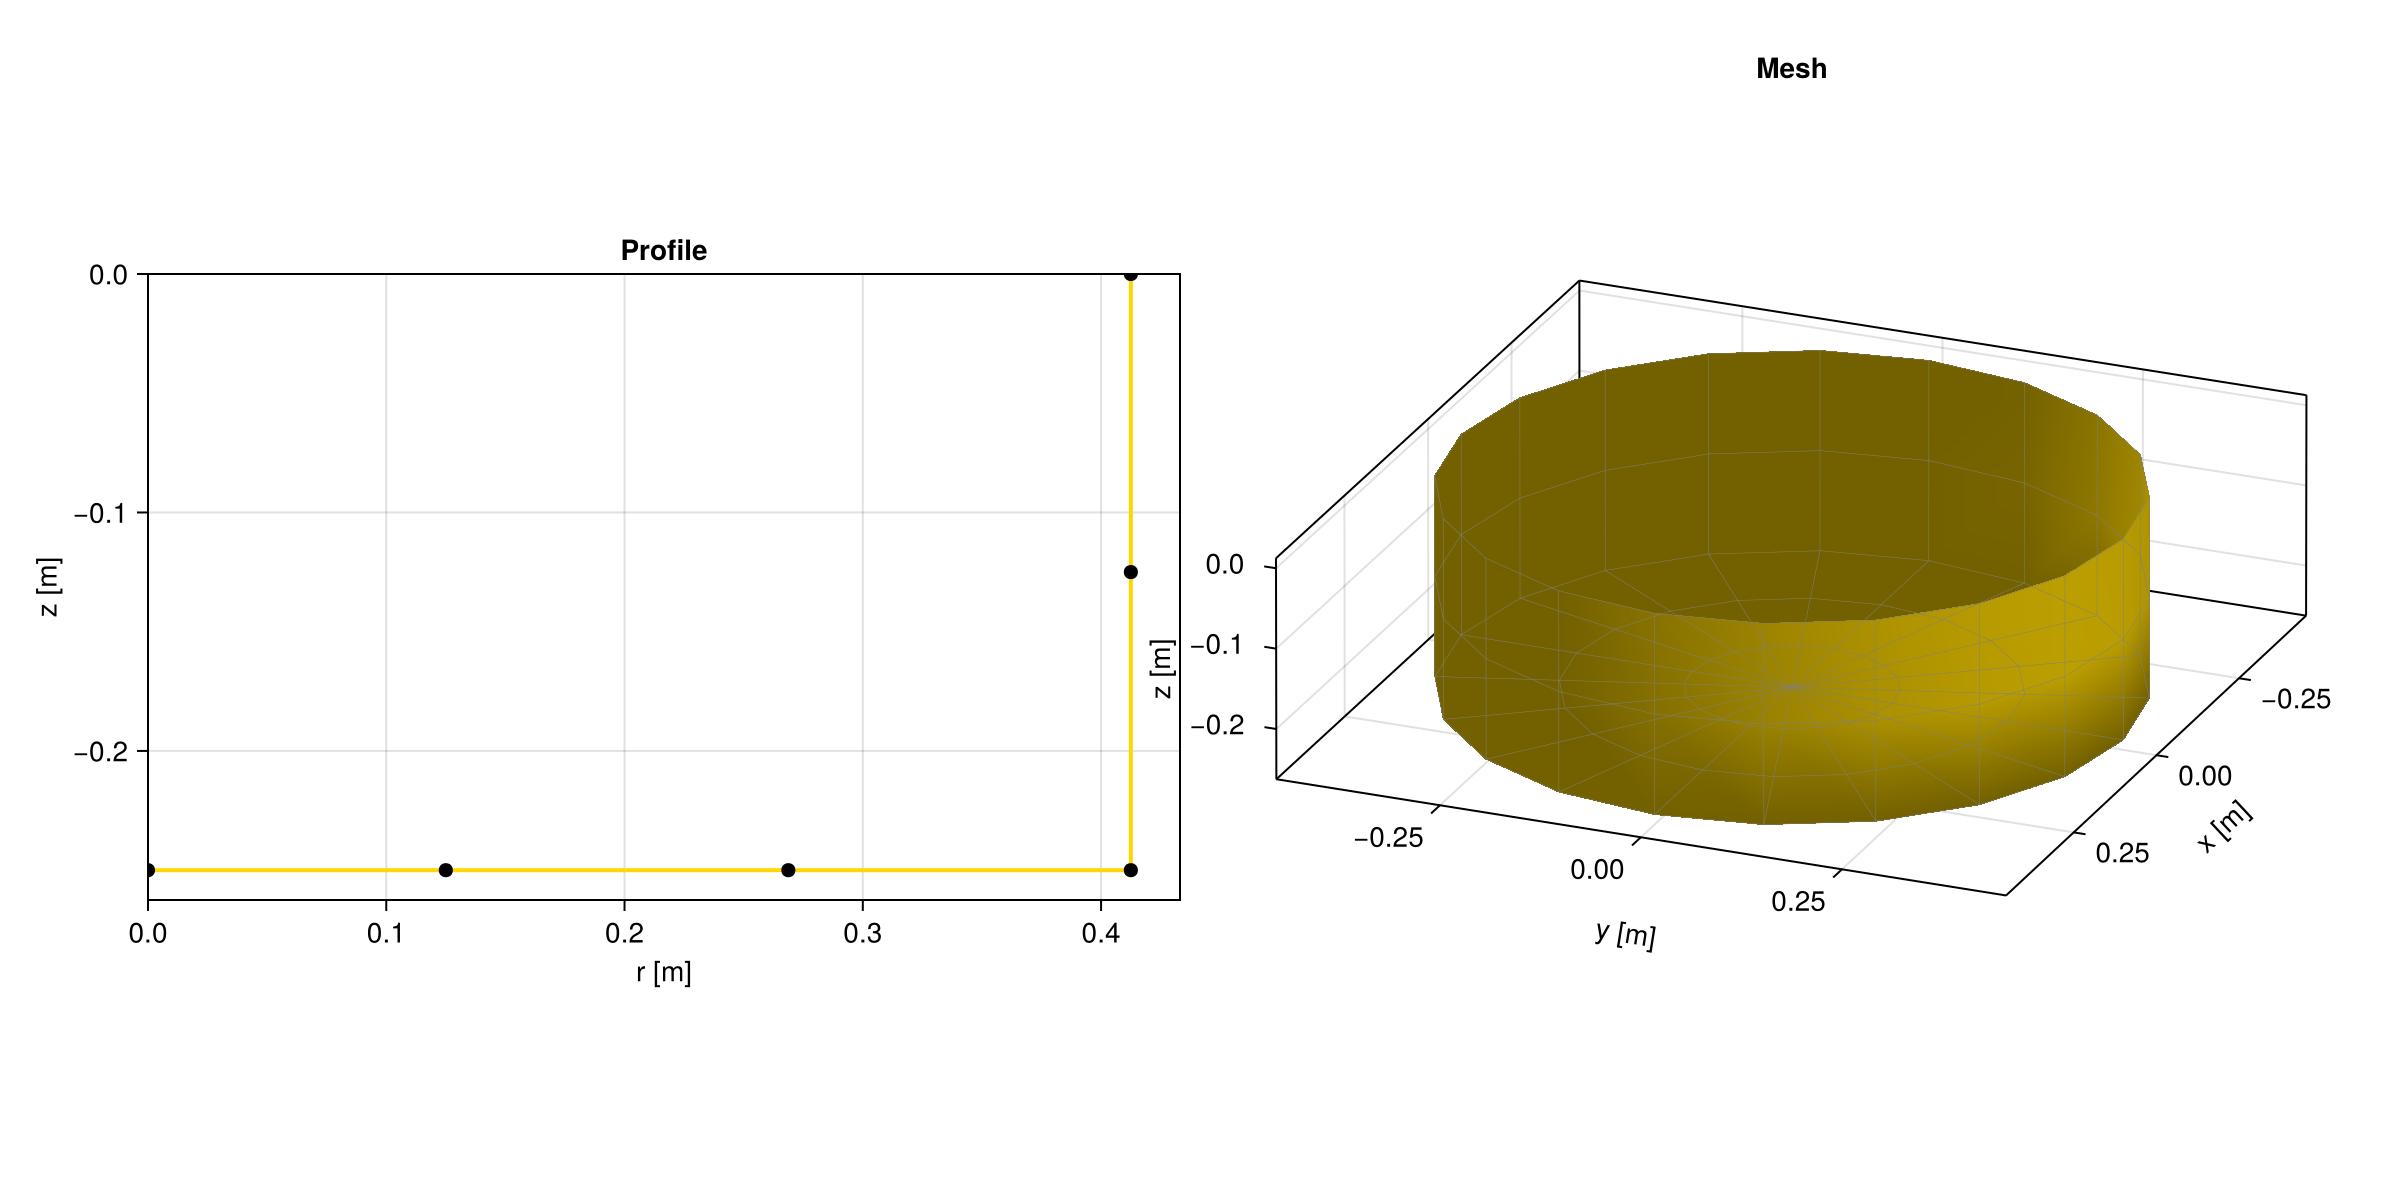

Mesh([0.41250000000000003 0.0 -0.0; 0.39231081297175086 0.12746951017966582 -0.0; … ; 0.11888206453689419 -0.03862712429686845 -0.25; 0.0 0.0 -0.25], [0 20 21 1; 1 21 22 2; … ; 98 100 99 99; 99 100 80 80], Number[0.4024054064858754 0.06373475508983291 -0.0625; 0.3630151615757083 0.1849654633751555 -0.0625; … ; 0.07333639627792087 -0.03736676027780921 -0.25; 0.08129402151229807 -0.012875708098956152 -0.25], Number[0.9876883405951377 0.15643446504023106 0.0; 0.8910065241883679 0.45399049973954664 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.01613230420727381, 0.01613230420727381, 0.01613230420727381, 0.016132304207273806, 0.01613230420727381, 0.016132304207273806, 0.016132304207273813, 0.016132304207273802, 0.016132304207273816, 0.016132304207273806  …  0.0024141952685542735, 0.00241419526855428, 0.002414195268554276, 0.002414195268554277, 0.0024141952685542765, 0.0024141952685542765, 0.0024141952685542765, 0.002414195268554277, 0.0024141952685542774, 0.0024141952685542783], Number[0.0898346

In [5]:
r1 = r_side[1]
r2 = 0.125
d1 = draft
d2 = 0.0
n_points = (2, 3, 3)
n_theta = 20
show_plot = true


wb_mesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

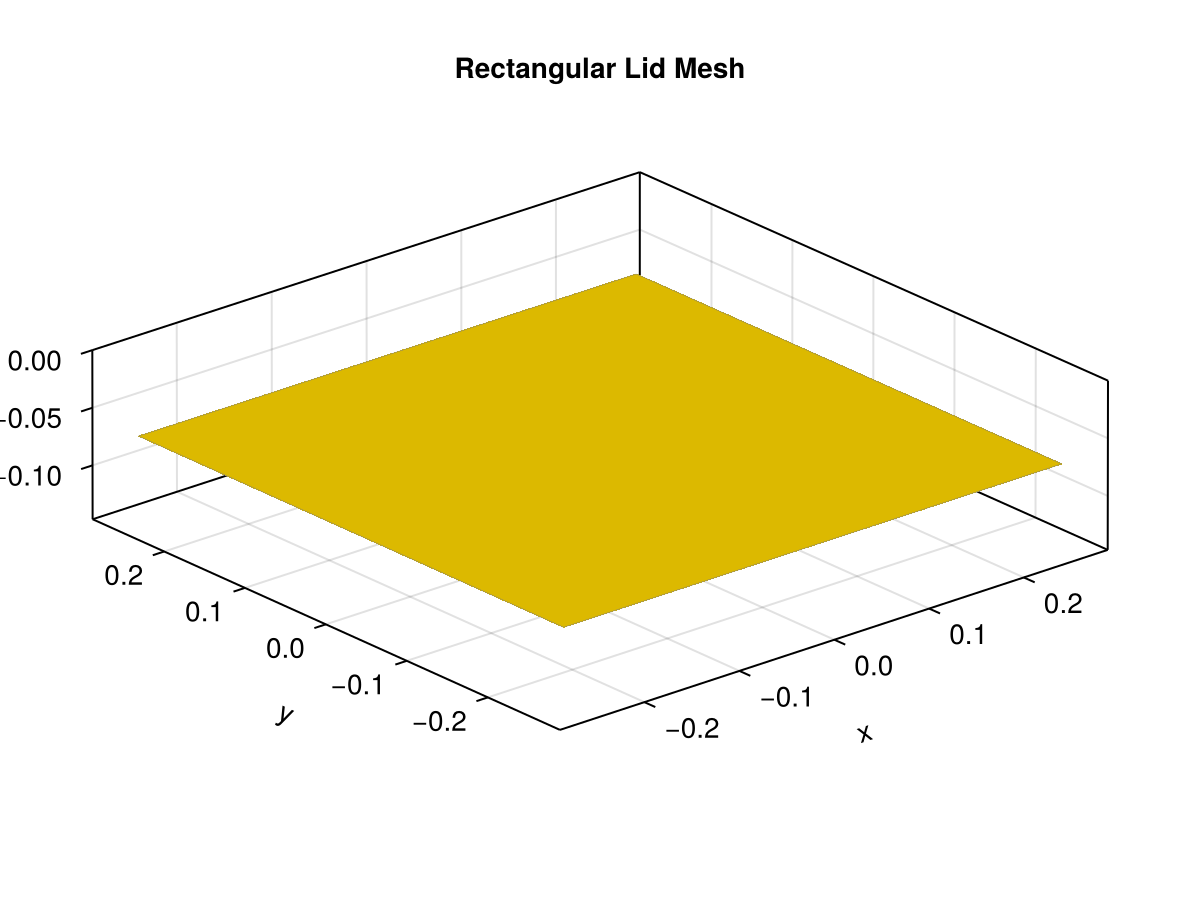

Mesh([-0.26251339251550576 -0.26251339251550576 -0.0734083; 0.26251339251550576 -0.26251339251550576 -0.0734083; -0.26251339251550576 0.26251339251550576 -0.0734083; 0.26251339251550576 0.26251339251550576 -0.0734083], [0 1 3 2], Number[0.0 0.0 -0.0734083], Number[0.0 0.0 1.0], [0.275653125], Number[0.37125], 4, 1)

In [6]:
radius_at_surface = maximum(r_side)
x_mean = 0.0
y_mean = 0.0
reduce_scale = 0.9
width = radius_at_surface * (2/sqrt(2)) * reduce_scale
x_min_lid = x_mean - width/2
x_max_lid = x_mean + width/2
y_min_lid = y_mean - width/2
y_max_lid = y_mean + width/2
z_value = -0.0734083
faces_max_radius = 1.4

lid_mesh = generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius,true)



In [7]:
# Hydrostatics
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

# Radiation
function radiation_program(mesh, omega, dof) 
    A, B = calculate_radiation_forces(mesh,dof,omega)
    # display("Damping: $B")
    return [A, B]
end

# Diffraction
function diffraction_program(mesh, omega, dof) 
    F_D = DiffractionForce(mesh,omega,dof)
    return [real(F_D),imag(F_D)]
end

function incident_program(mesh, omega, dof) 
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    return [real(F_FK),imag(F_FK)]
end

# Everything
dof = [0.0,0.0,1.0]

function compute_for_omega(mesh, omega)

    # M, K = hydrostatic_program(r1, r2, d1, d2)
    A, B = radiation_program(mesh, omega, dof)
    F_D_real, F_D_imag = diffraction_program(mesh, omega, dof) 
    F_FK_real, F_FK_imag = incident_program(mesh, omega, dof)
    # add negatives to imag since wot uses +i omega t instead of -i omega t
    return [A, B, F_D_real, -F_D_imag, F_FK_real, -F_FK_imag]
end

backend = AutoForwardDiff()


function arbitrary_axisymmetric_mesh(x)
    return arbitrary_axisymmetric_mesh(x, 20, 3, false)
end
    


function compute_vals1(x, omegas)
    set_rho!(1025.0)
    x=vec(x)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)
    results_per_omega = [compute_for_omega(mesh, omega) for omega in omegas]
    vec_reduced = reduce(vcat, results_per_omega)
    
    return [M_val; K_val; vec_reduced]
end

function compute_all1(x_val, omegas)
    return value_and_jacobian(x -> compute_vals1(x, omegas), backend, x_val)
end


function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end


function centers(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(abs.(MH_mesh.centers[:,1]))
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [8]:
# using Plots

# omega = 2*pi*0.3
# num_omegas = 20
# omegas = collect(range(omega/2,6*omega,length=num_omegas))
# betas = [0.0]

# rigid_dof_list = ["Heave"]
# rotation_center = [0.0,0.0,0.0]

# parameters = (wave_frequencies=omegas, 
#     wave_directions=betas,
#     radiating_dofs=Symbol.(rigid_dof_list),
#     influenced_dofs=Symbol.(rigid_dof_list))

# # No lid
# floatingbody_no_lid = FloatingBody(ax_mesh, rigid_dof_list, rotation_center, "axisymmetric_fb")
# mhresults_no_lid = compute_hydrodynamic_coefficients(parameters, floatingbody_no_lid)

# # With lid
# floatingbody_with_lid = FloatingBody(ax_mesh, lid_mesh, rigid_dof_list, rotation_center, "axisymmetric_fb_with_lid")
# mhresults_with_lid = compute_hydrodynamic_coefficients(parameters, floatingbody_with_lid)


In [9]:
# plot(omegas, vec(mhresults_no_lid.added_mass),
#     label="A (no lid)", xlabel="Omega", ylabel="Values",
#     linewidth=2, marker=:circle, markersize = 6)
# plot!(omegas, vec(mhresults_no_lid.radiation_damping),
#     label="B (no lid)", linewidth=2, marker=:square, markersize = 6)
# plot!(omegas, vec(mhresults_with_lid.added_mass),
#     label="A (with lid)", linewidth=1, marker=:circle, markersize = 4)
# plot!(omegas, vec(mhresults_with_lid.radiation_damping),
#     label="B (with lid)", linewidth=1, marker=:square, markersize = 4)

In [10]:
# using PyCall
# cpt = pyimport("capytaine")

# cpt_mesh = cpt.mesh_vertical_cylinder(
#     length=draft*2, radius=radius_at_surface, center=(0, 0, 0), faces_max_radius=faces_max_radius/2,
#     ).immersed_part()
# cpt_lid_mesh = cpt_mesh.generate_lid(z=cpt_mesh.lowest_lid_position(omega_max=maximum(omegas)))
# width_of_lid = 2*maximum(cpt_lid_mesh.vertices[:,1])
# println("Width of lid: $width_of_lid")
# println("Z depth: $(cpt_lid_mesh.vertices[1,1])")


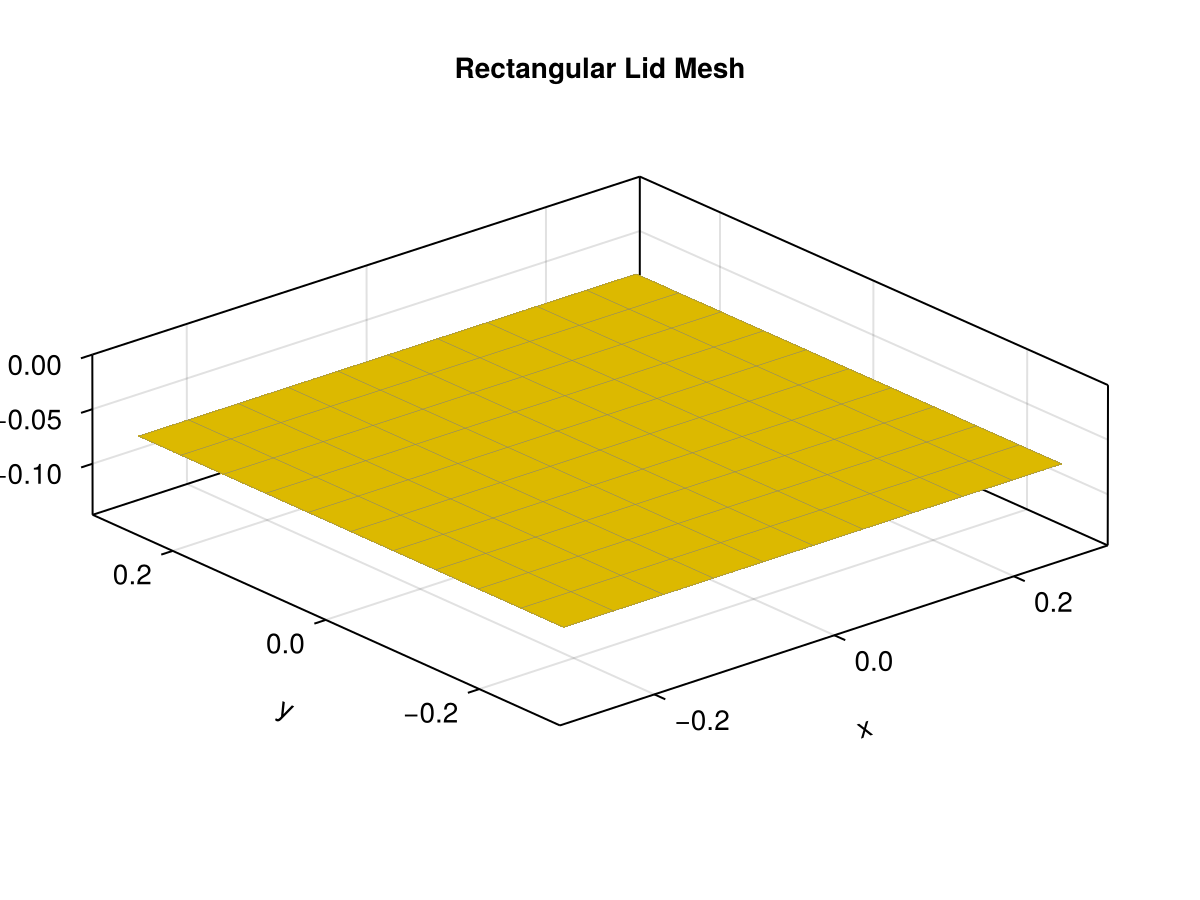

Mesh([-0.2770974698774783 -0.2770974698774783 -0.0734083; -0.22167797590198263 -0.2770974698774783 -0.0734083; … ; 0.22167797590198263 0.2770974698774783 -0.0734083; 0.2770974698774783 0.2770974698774783 -0.0734083], [0 1 12 11; 1 2 13 12; … ; 107 108 119 118; 108 109 120 119], Number[-0.2493877228897305 -0.2493877228897305 -0.0734083; -0.19396822891423482 -0.2493877228897305 -0.0734083; … ; 0.19396822891423482 0.2493877228897305 -0.0734083; 0.2493877228897305 0.2493877228897305 -0.0734083], Number[0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 1.0; 0.0 0.0 1.0], [0.003071320312500001, 0.003071320312499999, 0.003071320312499999, 0.003071320312500001, 0.003071320312500001, 0.003071320312499998, 0.003071320312500001, 0.003071320312500001, 0.003071320312500001, 0.003071320312500001  …  0.003071320312500001, 0.003071320312499999, 0.003071320312499999, 0.003071320312500001, 0.003071320312500001, 0.003071320312499998, 0.003071320312500001, 0.003071320312500001, 0.003071320312500001, 0.003071320312500

In [11]:
# function for lid

function generate_lid_for_axisymmetric_geom(x, show_lid)

    # fixed parameters
    x_mean = 0.0
    y_mean = 0.0
    reduce_scale = 0.95
    n_panels_x = 10
    n_panels_y = 10
    z_value = -0.0734083

    # changable parameters
    radius_at_surface = r_side[1]
    width = radius_at_surface * (2/sqrt(2)) * reduce_scale
    x_min_lid = x_mean - width/2
    x_max_lid = x_mean + width/2
    y_min_lid = y_mean - width/2
    y_max_lid = y_mean + width/2   

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end

function generate_lid_for_axisymmetric_geom(x_val)
    return generate_lid_for_axisymmetric_geom(x_val, false)
end



show_lid=true
lid_mesh = generate_lid_for_axisymmetric_geom(x_val, show_lid)
generate_lid_for_axisymmetric_geom(x_val)

In [12]:
# Make one big compute function
function compute_vals(x, omegas, with_lid)
    set_rho!(1025.0)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)

    betas = [0.0]
    rigid_dof_list = ["Heave"]
    rotation_center = [0.0,0.0,0.0]

    parameters = (wave_frequencies=omegas, 
        wave_directions=betas,
        radiating_dofs=Symbol.(rigid_dof_list),
        influenced_dofs=Symbol.(rigid_dof_list))

    # Method
    direct=true

    # Green's function
    gf="Wu"

    if with_lid
        lid_mesh = generate_lid_for_axisymmetric_geom(x, false)
        floatingbody_with_lid = FloatingBody(mesh, lid_mesh, rigid_dof_list, rotation_center, "axisymmetric_fb_with_lid")
        mhresults = compute_hydrodynamic_coefficients(parameters, floatingbody_with_lid, direct=direct, gf=gf)
    else
        floatingbody_no_lid = FloatingBody(mesh, rigid_dof_list, rotation_center, "axisymmetric_fb")
        mhresults = compute_hydrodynamic_coefficients(parameters, floatingbody_no_lid, direct=direct, gf=gf)
    end

    # Organize
    A = vec(mhresults.added_mass)
    B = vec(mhresults.radiation_damping)
    f_D = vec(mhresults.diffraction_force)
    f_FK = vec(mhresults.Froude_Krylov_force)
    hydrodynamic_data = collect(vec([A B real(f_D) -imag(f_D) real(f_FK) -imag(f_FK)]'))
    hydrodynamic_and_hydrostatic_data = [M_val; K_val; hydrodynamic_data]
    
    return hydrodynamic_and_hydrostatic_data
end

function compute_vals(x, omegas)
    return compute_vals(x, omegas, true)
end

# inputs
omega = 2*pi*0.3
num_omegas = 10
# omegas = collect(range(omega,10*omega,length=num_omegas))
omegas = [omega]

data = compute_vals(x_val, omegas)
data


8-element Vector{Float64}:
  136.43349073102559
 5375.150779403056
  169.12631922444766
   62.306164467465955
 -569.8308937747431
  118.31728478000178
 4816.561952581199
   -2.020605904817785e-14

In [13]:
arbitrary_axisymmetric_mesh(x_val)

Mesh([0.41250000000000003 0.0 0.0; 0.39231081297175086 0.12746951017966582 0.0; … ; 0.1307702709905836 -0.0424898367265553 -0.25; 0.0 0.0 -0.25], [0 20 21 1; 1 21 22 2; … ; 98 100 99 99; 99 100 80 80], Number[0.4024054064858754 0.06373475508983291 -0.0625; 0.3630151615757083 0.1849654633751555 -0.0625; … ; 0.08067003590571296 -0.04110343630559013 -0.25; 0.08942342366352789 -0.014163278908851766 -0.25], Number[0.9876883405951377 0.15643446504023106 0.0; 0.8910065241883679 0.45399049973954664 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.01613230420727381, 0.01613230420727381, 0.01613230420727381, 0.016132304207273806, 0.01613230420727381, 0.016132304207273806, 0.016132304207273813, 0.016132304207273802, 0.016132304207273816, 0.016132304207273806  …  0.0029211762749506713, 0.0029211762749506796, 0.002921176274950675, 0.0029211762749506752, 0.002921176274950675, 0.0029211762749506757, 0.0029211762749506744, 0.0029211762749506752, 0.002921176274950676, 0.002921176274950677], Number[0.0898346805

In [14]:
backend = AutoForwardDiff()
function compute_all(x_val, omegas)
    return value_and_jacobian(x -> compute_vals(x, omegas), backend, x_val)
end

all_data = compute_all(x_val, omegas)

([136.43349073102559, 5375.150779403056, 169.12631922444766, 62.306164467465955, -569.8308937747431, 118.31728478000178, 4816.561952581199, -2.020605904817785e-14], [165.37392815881884 330.7478563176377 165.37392815881884 547.9256655864481; 26061.337112257235 0.0 0.0 0.0; … ; 24924.74901833877 -1103.2657552768421 -530.9697331569786 -1744.4976530390786; 1.7053025658242404e-13 -1.9895196601282805e-13 -1.1812772982011666e-13 8.104628079763643e-15])

In [15]:
# with lid (ntheta=20, scale=0.95, 10x10)
all_data[2]

8×4 Matrix{Float64}:
   165.374         330.748          165.374          547.926
 26061.3             0.0              0.0              0.0
   618.395          -9.12675        613.299          -53.777
   601.816         -37.0184          -1.13785        -43.37
 -2294.1          -283.479        -1550.07           328.211
  1130.27          -80.3231          20.215          -75.022
 24924.7         -1103.27          -530.97         -1744.5
     1.7053e-13     -1.98952e-13     -1.18128e-13      8.10463e-15

In [16]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> compute_vals(x, [omega]), x_val)[1]


8×4 Matrix{Float64}:
   165.374          330.748          165.374          547.926
 26061.3             -6.3215e-10      -1.02844e-9      -1.00378e-9
   672.948           44.3735         505.794          -54.1831
   659.925          -35.6912         -60.5697         -43.2925
 -2505.75          -115.505        -1508.23           329.552
  1241.55           -64.9725        -106.397          -74.8914
 24924.7          -1103.27          -530.97         -1744.5
    -5.97759e-11     -6.57964e-27     -4.26844e-11     -2.50618e-10

In [17]:
max_rel_error = maximum(abs.(J-all_data[2]))
println("The maximum relative error is: $max_rel_error")

The maximum relative error is: 211.6517524215642


In [18]:
# wrt omega correct?
grad_wrt_omega = value_and_derivative(o -> compute_vals(x_val, [o]), backend, omega)

([136.43349073102559, 5375.150779403056, 169.12631922444763, 62.30616446746594, -569.8308937747431, 118.31728478000178, 4816.561952581199, -2.020605904817785e-14], [0.0, 0.0, -18.05187435256994, 69.92406396195412, -508.5645418665142, 197.3930817246333, -490.1033098700868, -2.886579864025407e-15])

In [19]:
grad_wrt_omega[2]

8-element Vector{Float64}:
    0.0
    0.0
  -18.05187435256994
   69.92406396195412
 -508.5645418665142
  197.3930817246333
 -490.1033098700868
   -2.886579864025407e-15

In [20]:
J = FiniteDifferences.jacobian(method, o -> compute_vals(x_val, [o]), omega)[1]


8×1 Matrix{Float64}:
    3.3611131422627705e-12
   -3.585187351746955e-11
  -18.051874352468616
   69.92406396191693
 -508.56454186636586
  197.39308172456046
 -490.10330987046297
   -5.7944190108800884e-12

In [21]:
z_evals = collect(range(0, 5, length=3))
r_side = 2 * (1.0 .+ 0.5*cos.(z_evals*(2*pi/5)))

3-element Vector{Float64}:
 3.0
 1.0
 3.0

In [22]:
# design vars to r_vals 









In [23]:
# try redefining derivative of radii



function Radius_to_x(Radius)
    Draft = draft 
    n_side = 4-1 # number of design vars-1 (draft is also a design var)
    z_evals = collect(range(0, Draft, length=n_side))
    R_0 = 0.41250000000000003
    r_side = ones(n_side) * R_0
    r_side += (Radius-R_0) * (0.5*cos.(z_evals*(2*pi/Draft)))
    # r_side = ones(n_side) * Radius
    x = vcat(r_side,Draft)
    return x
end

function Radius_omegas_to_vals(Radius,omegas)
    x_val = Radius_to_x(Radius)
    vals = compute_vals(x_val, omegas)
    return vals
end



Radius_omegas_to_vals (generic function with 1 method)

In [24]:
Radius_val = (radii_upper+radii_lower)/2 * 0.75

0.41250000000000003

In [25]:
Radius_val = (radii_upper+radii_lower)/2 * 0.75
out = value_and_derivative(R -> Radius_omegas_to_vals(R,omegas), backend, Radius_val)
out[2]

8-element Vector{Float64}:
     0.0
 13030.668556128618
  -734.2090322255957
  1005.9794892154248
  3249.872671121169
  1993.0093055970426
 12748.522520229319
     1.6830981053317373e-13

In [26]:
J2 = FiniteDifferences.jacobian(method, R -> Radius_omegas_to_vals(R,omegas), Radius_val)[1]


8×1 Matrix{Float64}:
    -7.058918833188033e-11
 13030.668556104141
  -771.8634455169365
  1004.586683276096
  3002.6306153917585
  1992.9661515765324
 12748.522520224098
     2.420988568569958e-10

In [27]:
# verify the issue is not the mesh function
function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end

v_and_grad = value_and_gradient(x -> surface_area(x), backend, x_val)
v_and_grad[2]

4-element Vector{Float64}:
 0.39108616260057705
 0.7821723252011545
 2.940476366193899
 2.58116867316381

In [28]:
J3 = FiniteDifferences.jacobian(method, x -> surface_area(x), x_val)[1]


1×4 Matrix{Float64}:
 0.391086  0.782172  2.94048  2.58117